# Step 1 — Data loading & exploration

**Project:** World Cup prediction ensemble (Elo + Dixon-Coles + neural network, simulated with Monte Carlo)

**Goal of this notebook:** load the historical international match results, check data quality, clean it, and understand the patterns the models will learn from.

**Data source:** [martj42/international_results](https://github.com/martj42/international_results), an open dataset of men's international football results since 1872 (also on Kaggle as *International football results from 1872 to …*).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 4)

## 2. Load the data

We read the CSV straight from GitHub, so nothing needs uploading.

If this cell fails, download `results.csv` from the Kaggle dataset, upload it with the folder icon on the left in Colab, and change `URL` to `"results.csv"`.

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
raw = pd.read_csv(URL, parse_dates=["date"])

print(f"Rows: {len(raw):,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 49,945   Columns: 9


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


## 3. Understand the structure

**Grain:** one row per international match.

**Columns:** `date` (temporal) · `home_team`, `away_team`, `tournament`, `city`, `country` (dimensions) · `home_score`, `away_score` (metrics) · `neutral` (boolean: was the game at a neutral venue?)

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49945 entries, 0 to 49944
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49945 non-null  datetime64[ns]
 1   home_team   49945 non-null  object        
 2   away_team   49945 non-null  object        
 3   home_score  49945 non-null  int64         
 4   away_score  49945 non-null  int64         
 5   tournament  49945 non-null  object        
 6   city        49945 non-null  object        
 7   country     49945 non-null  object        
 8   neutral     49945 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.1+ MB


In [4]:
print("Date range:", raw["date"].min().date(), "to", raw["date"].max().date())
print("Distinct teams:", pd.unique(raw[["home_team", "away_team"]].values.ravel()).size)
print("Distinct tournaments:", raw["tournament"].nunique())

Date range: 1872-11-30 to 2026-10-06
Distinct teams: 337
Distinct tournaments: 225


## 4. Data quality checks

In [5]:
# Missing values per column
raw.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


In [6]:
# Rows with no score are usually fixtures that haven't been played yet
unplayed = raw[raw["home_score"].isna() | raw["away_score"].isna()]
print(f"Matches without a score: {len(unplayed)}")
unplayed.tail()

Matches without a score: 0


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral


In [7]:
# Exact duplicate rows, and the same fixture listed twice on one day
print("Exact duplicates:", raw.duplicated().sum())
print("Same date + teams duplicates:",
      raw.duplicated(subset=["date", "home_team", "away_team"]).sum())

Exact duplicates: 0
Same date + teams duplicates: 1


In [8]:
# Sanity checks: negative scores or extreme scorelines
print("Negative scores:", ((raw["home_score"] < 0) | (raw["away_score"] < 0)).sum())
raw.assign(total=raw["home_score"] + raw["away_score"]).nlargest(5, "total")[
    ["date", "home_team", "away_team", "home_score", "away_score", "tournament"]]

Negative scores: 0


,date,home_team,away_team,home_score,away_score,tournament
25437,2001-04-11,Australia,American Samoa,31,0,FIFA World Cup qualification
8553,1971-09-13,Tahiti,Cook Islands,30,0,South Pacific Games
11921,1979-08-30,Fiji,Kiribati,24,0,South Pacific Games
25434,2001-04-09,Australia,Tonga,22,0,FIFA World Cup qualification
30536,2006-11-24,Sápmi,Monaco,21,1,Viva World Cup


**Write your own notes here:** how many unplayed fixtures you found, whether there were duplicates, and whether the huge scorelines look real (some genuinely are, e.g. Australia 31–0 American Samoa in 2001).

## 5. Clean the data

Decisions (each one is a modelling choice you should be able to explain in an interview):

1. **Drop unplayed matches.** They have no result to learn from.
2. **Keep matches from 1990 onwards.** Football has changed a lot; very old matches add noise. We keep a long enough history for Elo ratings to settle.
3. **Add helper columns:** total goals, goal difference and the result from the home side's view.

In [9]:
START_YEAR = 1990

df = raw.dropna(subset=["home_score", "away_score"])
df = df[df["date"].dt.year >= START_YEAR].copy()

df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
df["total_goals"] = df["home_score"] + df["away_score"]
df["goal_diff"] = df["home_score"] - df["away_score"]
df["result"] = np.select([df["goal_diff"] > 0, df["goal_diff"] < 0],
                         ["home_win", "away_win"], default="draw")

print(f"Clean matches since {START_YEAR}: {len(df):,}")

Clean matches since 1990: 32,821


## 6. Explore the patterns

### 6a. How often does each result happen? (and does home advantage exist?)

In [10]:
summary = (df.groupby("neutral")["result"]
             .value_counts(normalize=True)
             .unstack()
             .round(3))
summary.index = summary.index.map({False: "Home venue", True: "Neutral venue"})
summary

result,away_win,draw,home_win
neutral,,,
Home venue,0.259,0.234,0.507
Neutral venue,0.337,0.235,0.428


Compare home wins at a home venue with neutral venues. The gap is **home advantage**, and the Elo and Dixon-Coles models will need a parameter for it. At the World Cup almost all games are at neutral venues, except for the host nations.

### 6b. Goals per match over time

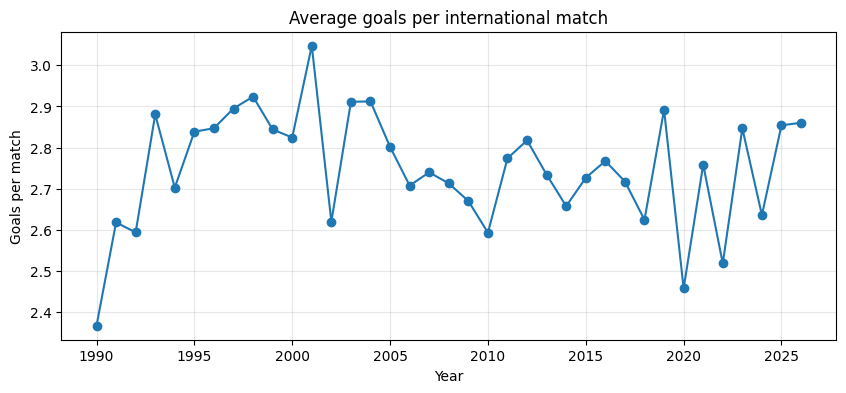

In [11]:
df.groupby(df["date"].dt.year)["total_goals"].mean().plot(marker="o")
plt.title("Average goals per international match")
plt.xlabel("Year"); plt.ylabel("Goals per match")
plt.grid(alpha=0.3); plt.show()

### 6c. Are goals Poisson distributed?

This is the key assumption behind the Dixon-Coles model: the number of goals a team scores follows a **Poisson distribution**. Let's test it by comparing the real distribution of home goals with a Poisson curve with the same mean.

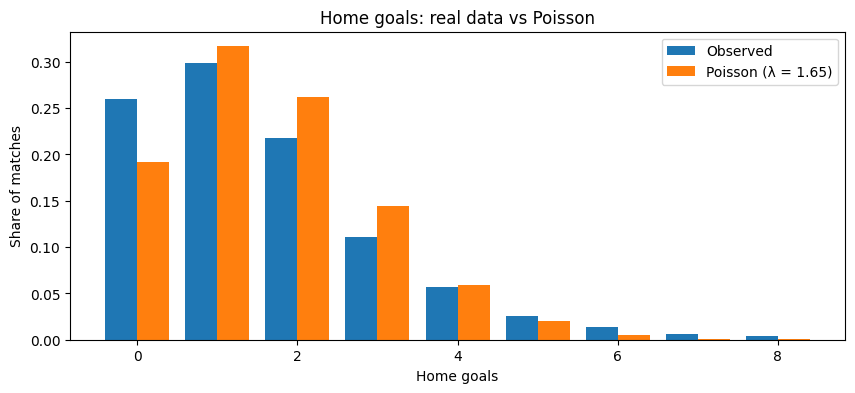

,observed,poisson
home_score,,
0,0.260,0.192
1,0.299,0.317
2,0.218,0.262
3,0.110,0.144
4,0.057,0.060
5,0.026,0.020
6,0.013,0.005
7,0.007,0.001
8,0.004,0.000


In [12]:
goals = df["home_score"]
lam = goals.mean()
k = np.arange(0, 9)

observed = goals.value_counts(normalize=True).reindex(k, fill_value=0)
expected = poisson.pmf(k, lam)

plt.bar(k - 0.2, observed, width=0.4, label="Observed")
plt.bar(k + 0.2, expected, width=0.4, label=f"Poisson (λ = {lam:.2f})")
plt.xlabel("Home goals"); plt.ylabel("Share of matches")
plt.title("Home goals: real data vs Poisson")
plt.legend(); plt.show()

pd.DataFrame({"observed": observed.round(3), "poisson": expected.round(3)})

**What to look for:** the fit is usually close, but real data tends to have **more low-scoring results** than a basic Poisson model predicts. That is the problem the Dixon-Coles correction fixes, and it's why we'll use it in Step 3. The next cell checks it directly.

In [13]:
# Observed 0-0 rate vs what two independent Poisson distributions predict
lam_h, lam_a = df["home_score"].mean(), df["away_score"].mean()
obs_00 = ((df["home_score"] == 0) & (df["away_score"] == 0)).mean()
exp_00 = poisson.pmf(0, lam_h) * poisson.pmf(0, lam_a)
print(f"0-0 observed: {obs_00:.3f}   expected under independent Poisson: {exp_00:.3f}")

0-0 observed: 0.088   expected under independent Poisson: 0.063


### 6d. Which tournaments make up the data?

In [14]:
df["tournament"].value_counts().head(15)

,count
tournament,
Friendly,10758
FIFA World Cup qualification,6977
UEFA Euro qualification,2114
African Cup of Nations qualification,1925
UEFA Nations League,762
FIFA World Cup,656
African Cup of Nations,642
AFC Asian Cup qualification,632
CFU Caribbean Cup qualification,508


Most matches are friendlies and qualifiers. Friendlies are less competitive, so later we'll give them **less weight** in Elo updates than World Cup or continental tournament games.

## 7. Save the cleaned data for the next steps

In [16]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/matches_clean.csv", index=False)
print("Saved data/matches_clean.csv")

Saved data/matches_clean.csv
